# EDA: Fraud_Data.csv

All data processing is delegated to `src.data_processing`. This notebook only visualises the results.

In [13]:
import sys
from pathlib import Path

proj_root = Path.cwd().resolve().parent
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from src.data_processing import (
    load_fraud_data, handle_cleaning, check_missing_values,
    check_duplicates, get_class_distribution, get_fraud_rate_by_column,
)

sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

## 1. Load & Clean

In [14]:
df = load_fraud_data()
print(f"Shape: {df.shape}")
df.head()

Shape: (151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


In [16]:
# Missing values
missing = check_missing_values(df)
print("Missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "None found")

Missing values:
None found


In [17]:
# Duplicates
dupes = check_duplicates(df)
print(f"Duplicate rows: {len(dupes)} ({len(dupes)/len(df)*100:.2f}%)")

# Clean
df = handle_cleaning(df)
print(f"Shape after cleaning: {df.shape}")

Duplicate rows: 0 (0.00%)
Missing values:
 user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64
Duplicate rows: 0
Shape after cleaning: (151112, 11)


### Duplicate Row Inspection

In [18]:
df_raw = load_fraud_data()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

dup_mask_all = df_raw.duplicated(keep=False)
duplicates_all = df_raw[dup_mask_all]

print(f"Total rows:                 {len(df_raw):,}")
print(f"Exact duplicate rows:       {len(df_raw[df_raw.duplicated()]):,} ({len(df_raw[df_raw.duplicated()])/len(df_raw)*100:.2f}%)")
print(f"Rows involved (all copies): {len(duplicates_all):,}")
n_groups = df_raw.duplicated(keep="first").sum()
print(f"Duplicate groups:           {n_groups:,}")
print("--- Sample of 5 duplicated rows (all columns) ---")
# duplicates_all.sample(5, random_state=42)

Total rows:                 151,112
Exact duplicate rows:       0 (0.00%)
Rows involved (all copies): 0
Duplicate groups:           0
--- Sample of 5 duplicated rows (all columns) ---


In [19]:
# Correct types
df["signup_time"] = pd.to_datetime(df["signup_time"])
df["purchase_time"] = pd.to_datetime(df["purchase_time"])
print("Datetime columns converted.")

Datetime columns converted.


## 2. Class Imbalance


Class Distribution (Fraud Data):
  Class 0: 136,961 (90.64%)
  Class 1: 14,151 (9.36%)
  Imbalance Ratio: 9.7:1


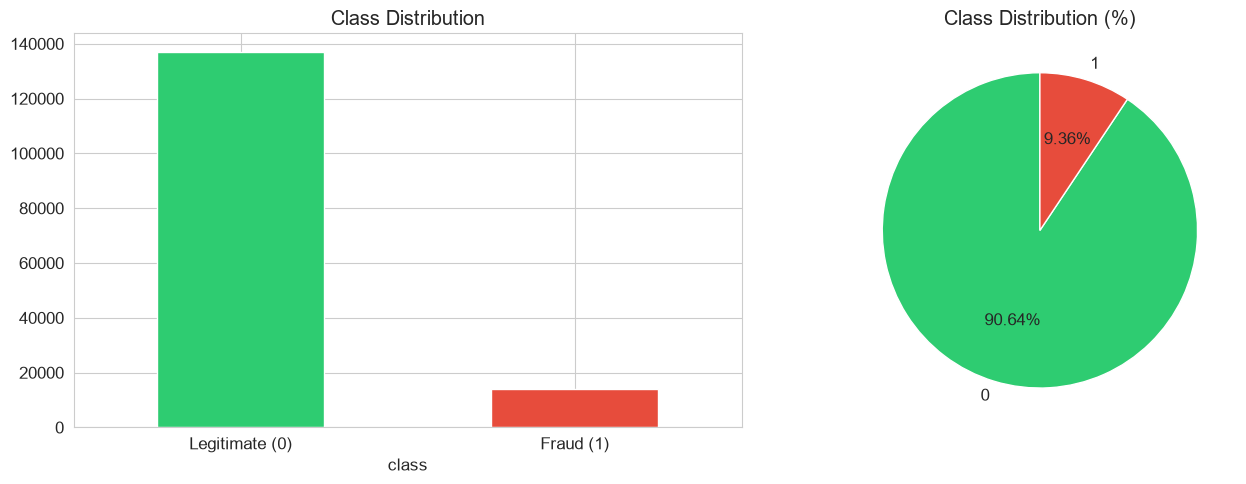

In [20]:
dist = get_class_distribution(df["class"], name="(Fraud Data)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df["class"].value_counts()
counts.plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_xticklabels(["Legitimate (0)", "Fraud (1)"], rotation=0)
axes[0].set_title("Class Distribution")

counts.plot.pie(ax=axes[1], colors=["#2ecc71", "#e74c3c"], autopct="%1.2f%%", startangle=90)
axes[1].set_ylabel("")
axes[1].set_title("Class Distribution (%)")
plt.tight_layout()
plt.show()

## 3. Univariate Analysis

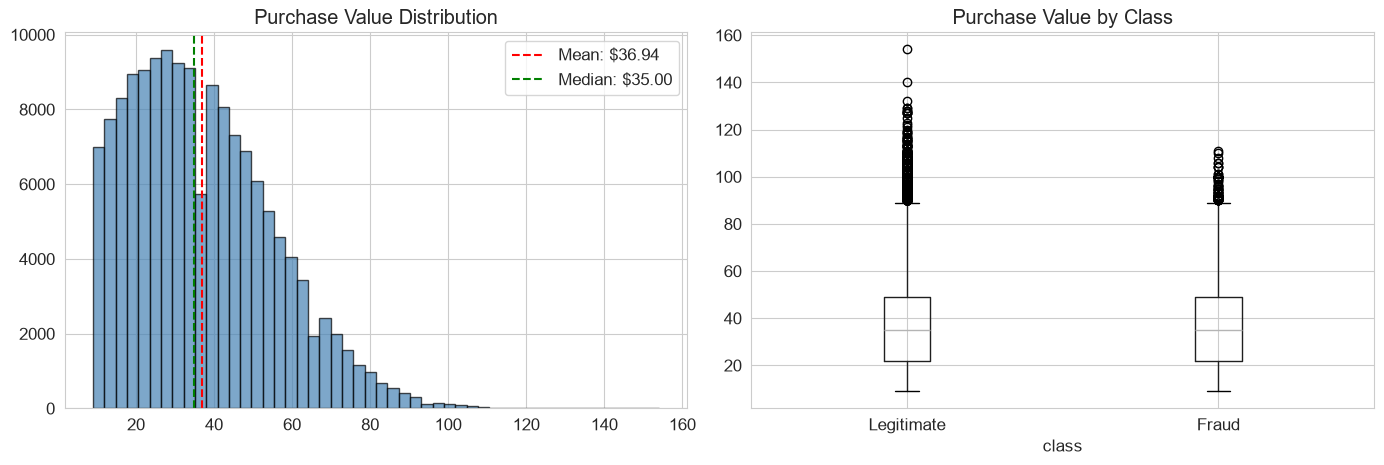

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["purchase_value"], bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(df["purchase_value"].mean(), color="red", ls="--", label=f'Mean: ${df["purchase_value"].mean():.2f}')
axes[0].axvline(df["purchase_value"].median(), color="green", ls="--", label=f'Median: ${df["purchase_value"].median():.2f}')
axes[0].legend()
axes[0].set_title("Purchase Value Distribution")

df.boxplot(column="purchase_value", by="class", ax=axes[1])
axes[1].set_title("Purchase Value by Class")
axes[1].set_xticklabels(["Legitimate", "Fraud"])
plt.suptitle("")
plt.tight_layout()
plt.show()

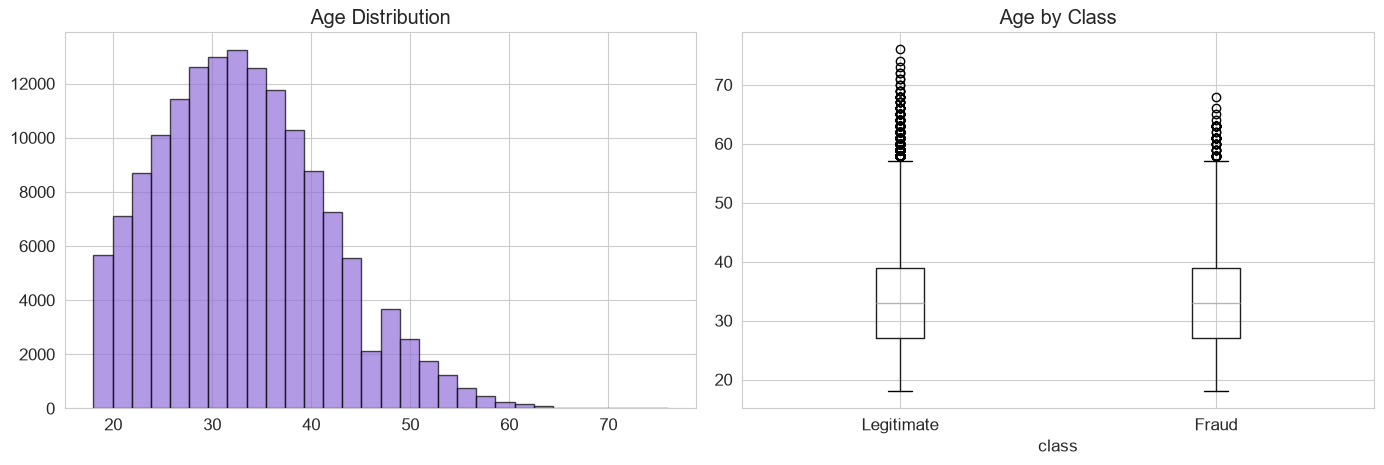

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["age"], bins=30, edgecolor="black", alpha=0.7, color="mediumpurple")
axes[0].set_title("Age Distribution")

df.boxplot(column="age", by="class", ax=axes[1])
axes[1].set_title("Age by Class")
axes[1].set_xticklabels(["Legitimate", "Fraud"])
plt.suptitle("")
plt.tight_layout()
plt.show()

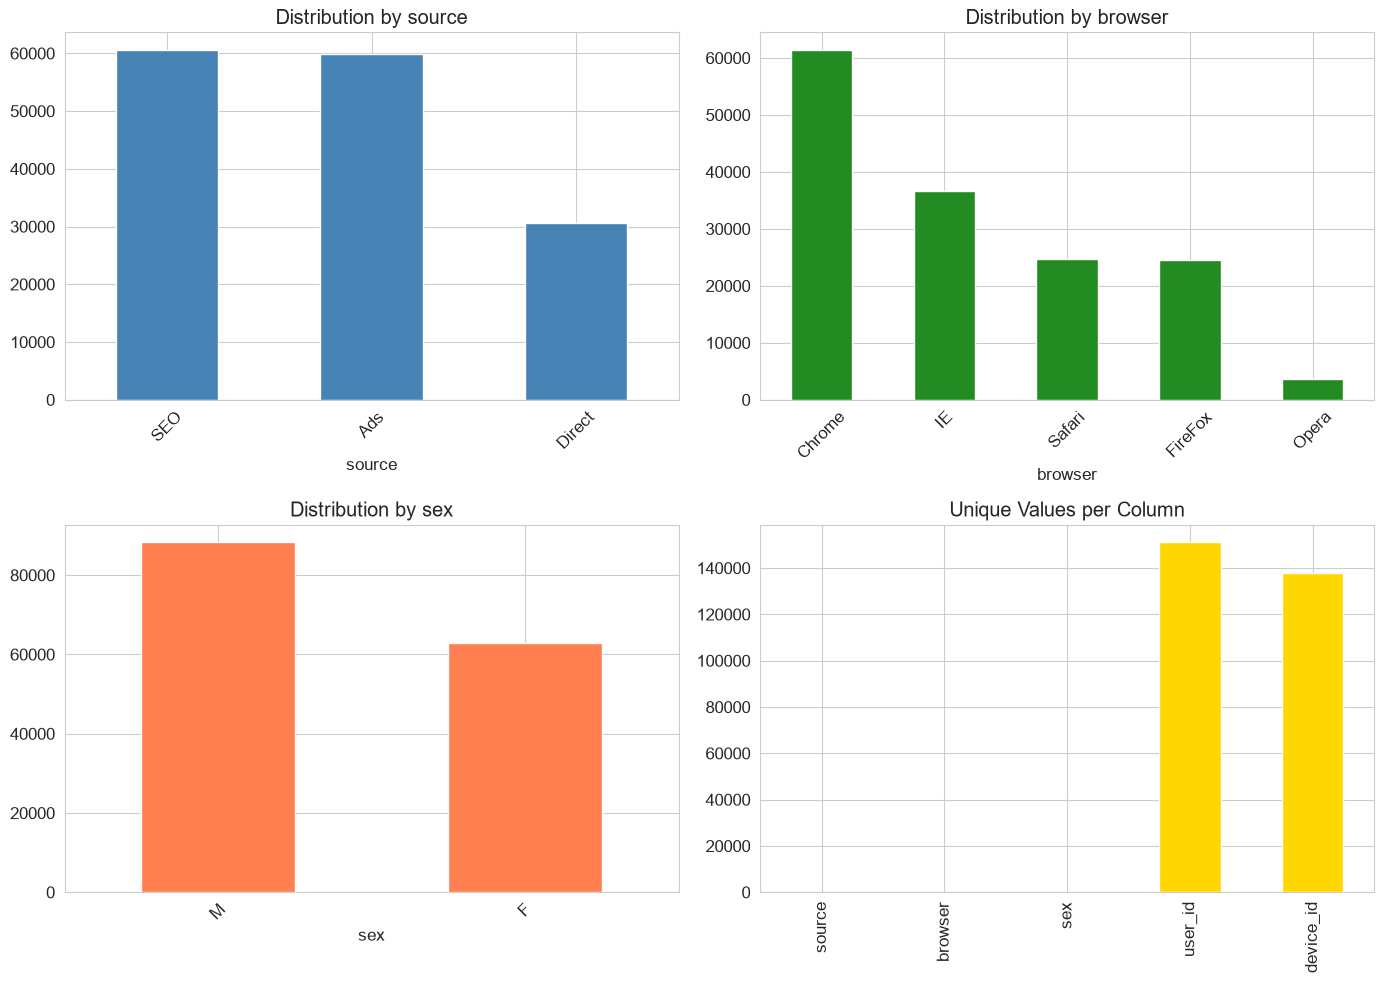

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, color in zip(axes.flat, ["source", "browser", "sex"], ["steelblue", "forestgreen", "coral"]):
    df[col].value_counts().plot.bar(ax=ax, color=color)
    ax.set_title(f"Distribution by {col}")
    ax.tick_params(axis="x", rotation=45)

unique_vals = df[["source", "browser", "sex", "user_id", "device_id"]].nunique()
unique_vals.plot.bar(ax=axes[1, 1], color="gold")
axes[1, 1].set_title("Unique Values per Column")
plt.tight_layout()
plt.show()

## 4. Bivariate Analysis


Fraud Rate by source:
        fraud_rate  total_transactions
source                                
Direct   10.536974               30616
Ads       9.206593               59881
SEO       8.928483               60615


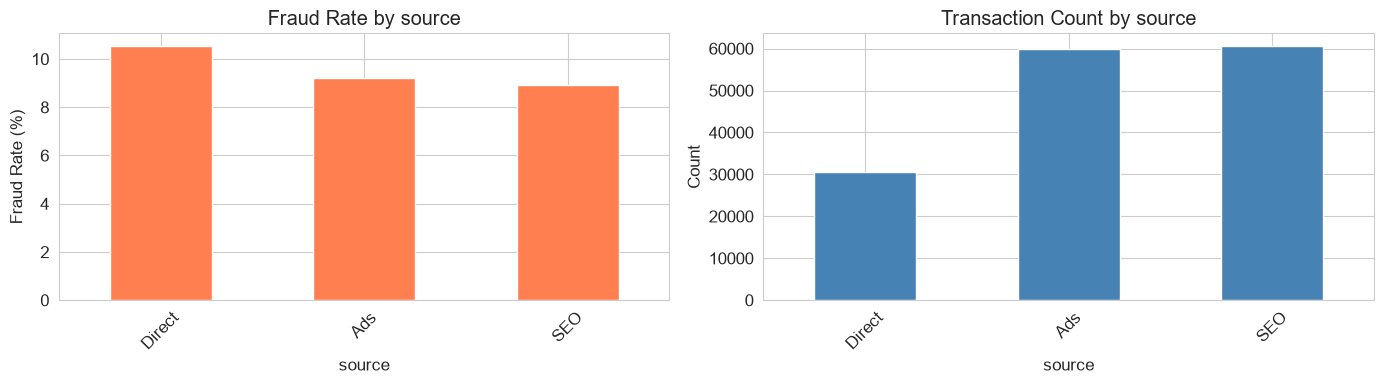


Fraud Rate by browser:
         fraud_rate  total_transactions
browser                                
Chrome     9.879216               61432
FireFox    9.516457               24610
Safari     9.020148               24667
Opera      8.922742                3676
IE         8.677540               36727


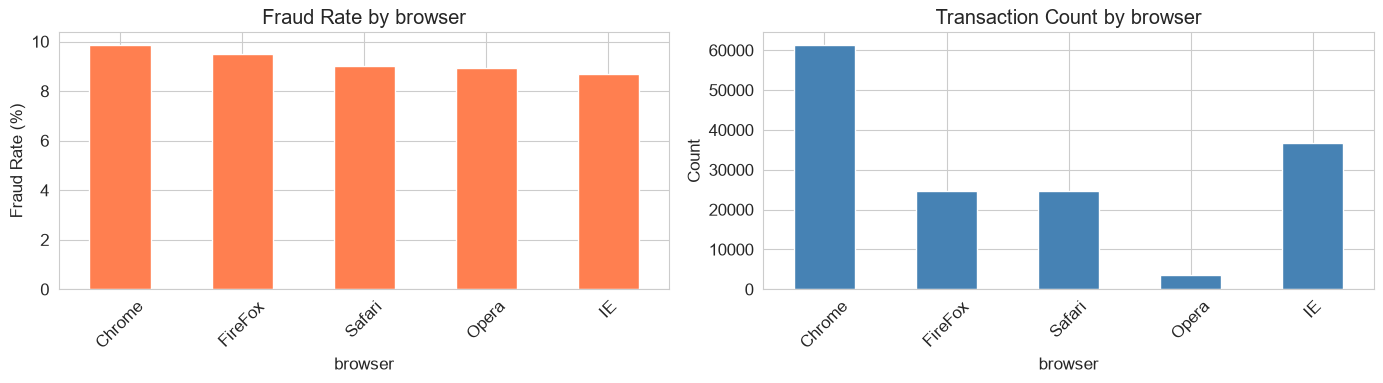


Fraud Rate by sex:
     fraud_rate  total_transactions
sex                                
M      9.552286               88293
F      9.100750               62819


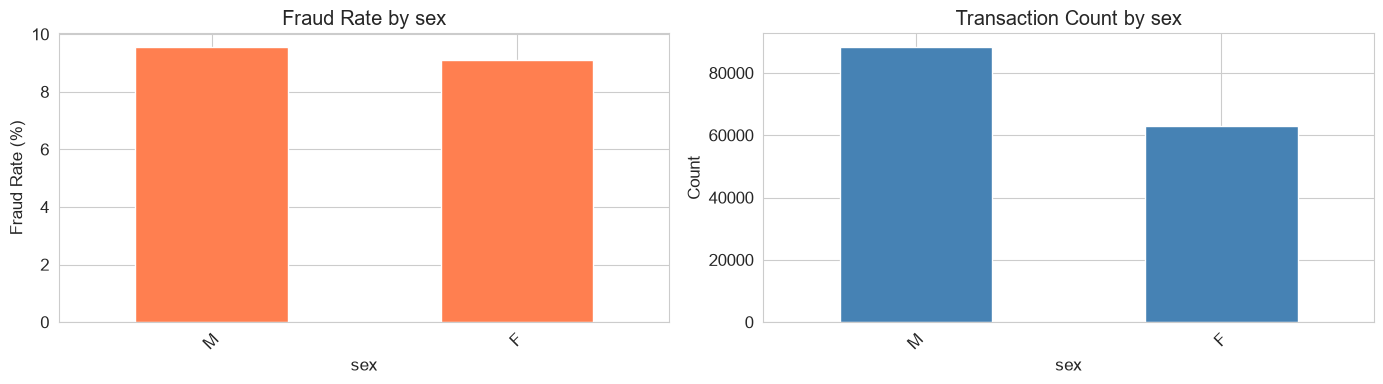

In [24]:
for col in ["source", "browser", "sex"]:
    stats = get_fraud_rate_by_column(df, col)
    print(f"\nFraud Rate by {col}:")
    print(stats)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    stats["fraud_rate"].plot.bar(ax=axes[0], color="coral")
    axes[0].set_title(f"Fraud Rate by {col}")
    axes[0].set_ylabel("Fraud Rate (%)")
    axes[0].tick_params(axis="x", rotation=45)
    stats["total_transactions"].plot.bar(ax=axes[1], color="steelblue")
    axes[1].set_title(f"Transaction Count by {col}")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

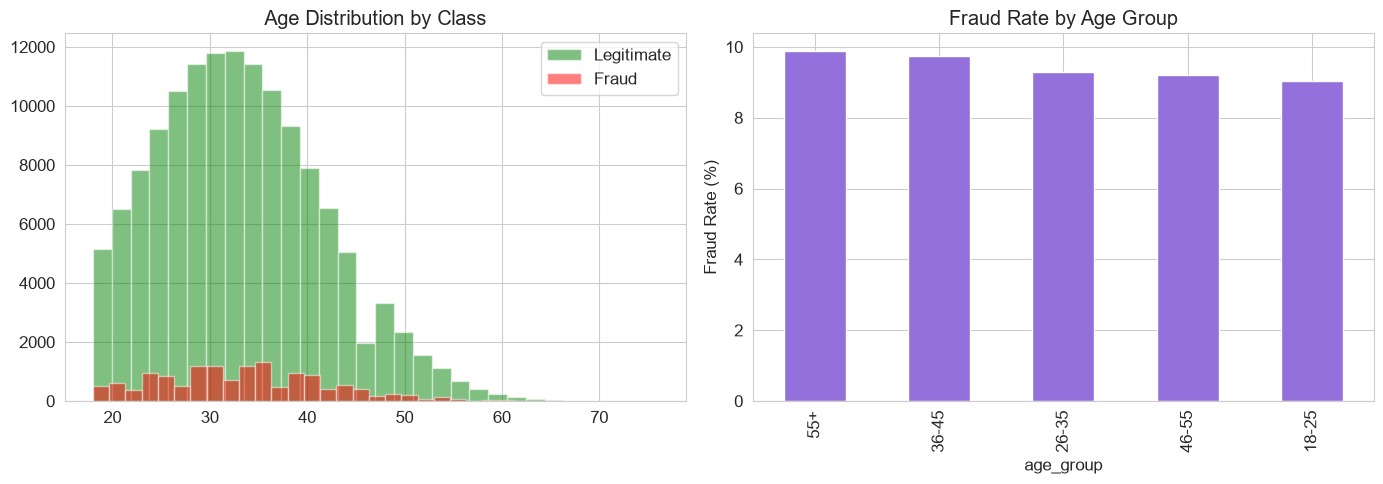

In [25]:
# Age groups vs fraud
df["age_group"] = pd.cut(df["age"], bins=[0, 25, 35, 45, 55, 100],
                          labels=["18-25", "26-35", "36-45", "46-55", "55+"])
fraud_by_age = get_fraud_rate_by_column(df, "age_group")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df[df["class"] == 0]["age"].hist(bins=30, alpha=0.5, label="Legitimate", ax=axes[0], color="green")
df[df["class"] == 1]["age"].hist(bins=30, alpha=0.5, label="Fraud", ax=axes[0], color="red")
axes[0].legend()
axes[0].set_title("Age Distribution by Class")

fraud_by_age["fraud_rate"].plot.bar(ax=axes[1], color="mediumpurple")
axes[1].set_title("Fraud Rate by Age Group")
axes[1].set_ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

Fraud Rate by Purchase Value Range:
           fraud_rate  total_transactions
value_bin                                
0-20         9.786343               32014
51-100       9.760371               33677
21-50        9.068380               85142
101-200      3.584229                 279


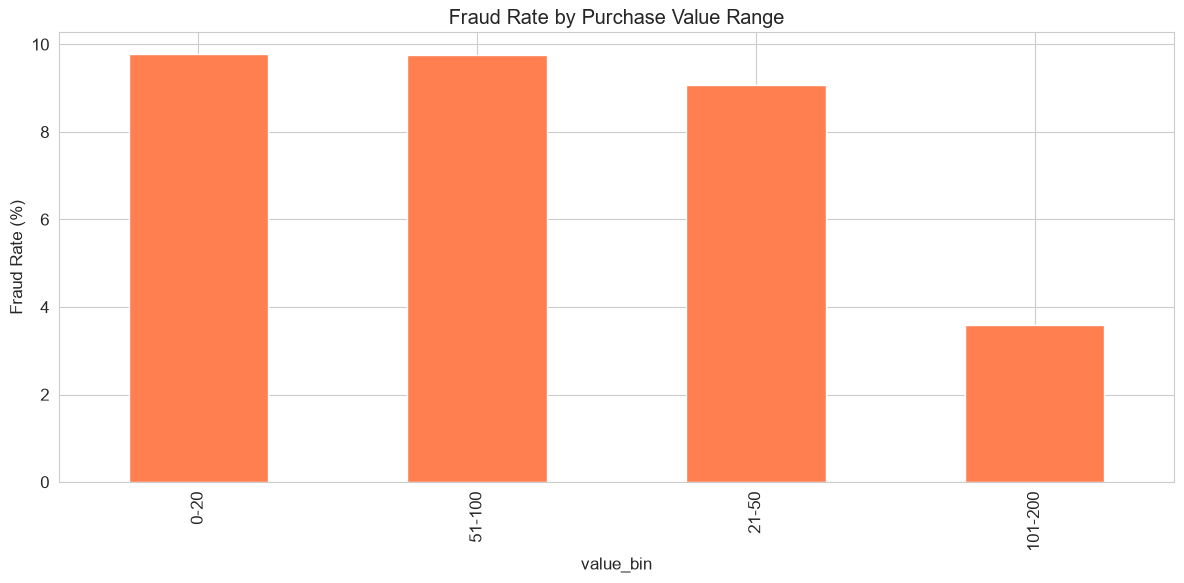

In [26]:
# Purchase value bins vs fraud
df["value_bin"] = pd.cut(df["purchase_value"], bins=[0, 20, 50, 100, 200, 500],
                          labels=["0-20", "21-50", "51-100", "101-200", "201-500"])
fraud_by_value = get_fraud_rate_by_column(df, "value_bin")
print("Fraud Rate by Purchase Value Range:")
print(fraud_by_value)

fraud_by_value["fraud_rate"].plot.bar(color="coral")
plt.title("Fraud Rate by Purchase Value Range")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

## 5. Temporal Analysis

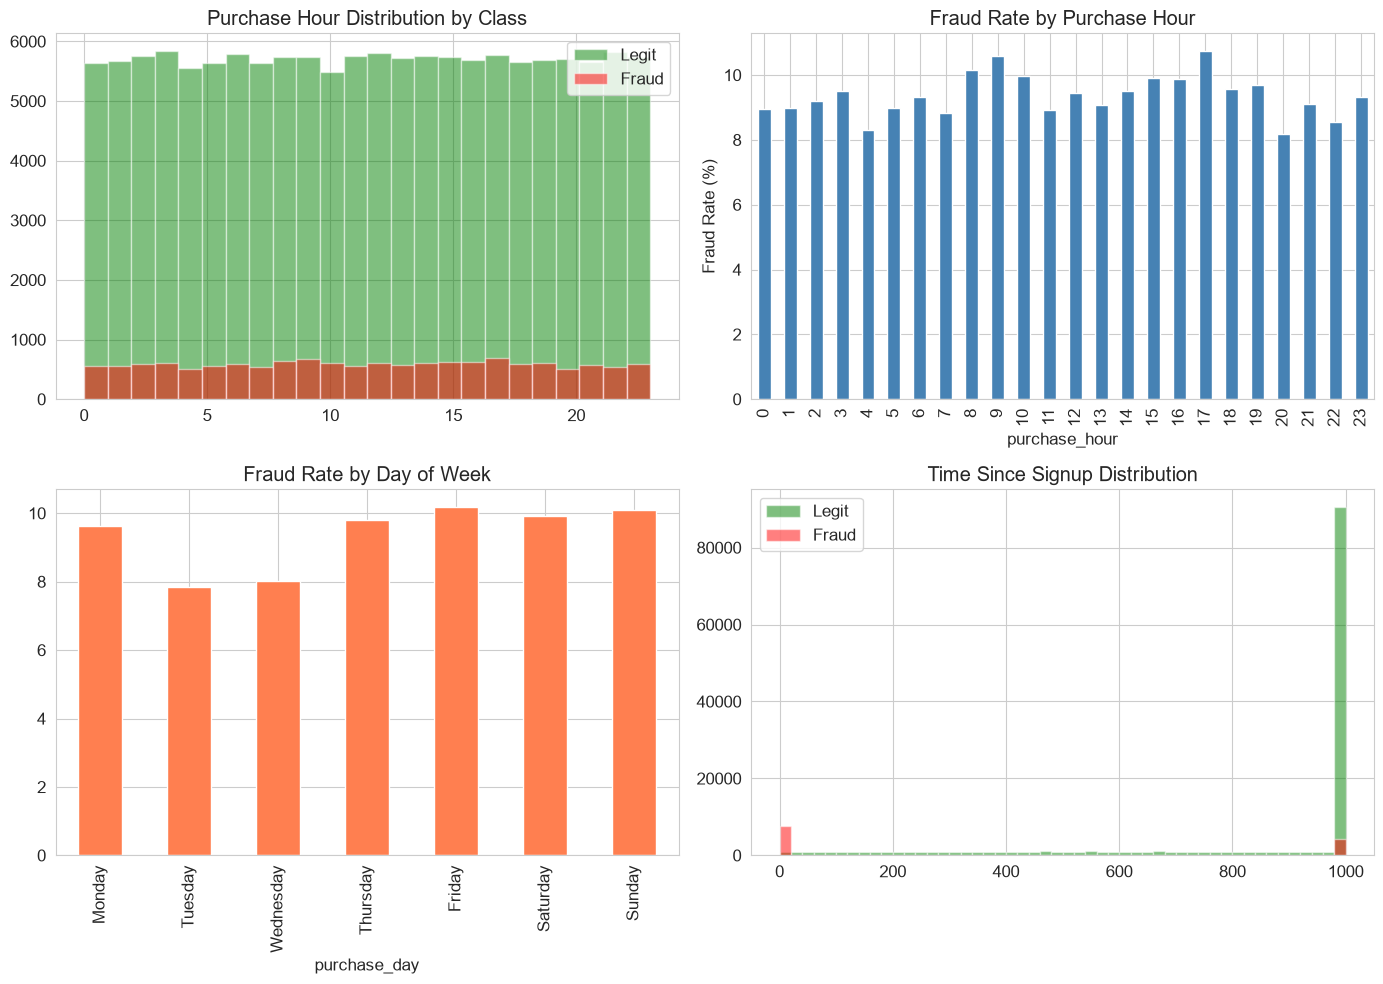


Time Since Signup Stats by Class:
          count         mean         std       min         25%          50%          75%          max
class                                                                                                
0      136961.0  1441.994052  830.163558  0.038056  719.119167  1443.030833  2161.477500  2879.992222
1       14151.0   673.289542  920.496897  0.000278    0.000278     0.000278  1330.697361  2878.874167


In [27]:
df["purchase_hour"] = df["purchase_time"].dt.hour
df["purchase_day"] = df["purchase_time"].dt.day_name()
df["time_since_signup"] = (df["purchase_time"] - df["signup_time"]).dt.total_seconds() / 3600

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hour distribution
df[df["class"] == 0]["purchase_hour"].hist(bins=24, alpha=0.5, label="Legit", ax=axes[0, 0], color="green")
df[df["class"] == 1]["purchase_hour"].hist(bins=24, alpha=0.5, label="Fraud", ax=axes[0, 0], color="red")
axes[0, 0].legend()
axes[0, 0].set_title("Purchase Hour Distribution by Class")

fraud_by_hour = df.groupby("purchase_hour")["class"].mean() * 100
fraud_by_hour.plot.bar(ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Fraud Rate by Purchase Hour")
axes[0, 1].set_ylabel("Fraud Rate (%)")

# Day distribution
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
fraud_by_day = (df.groupby("purchase_day")["class"].mean() * 100).reindex(day_order)
fraud_by_day.plot.bar(ax=axes[1, 0], color="coral")
axes[1, 0].set_title("Fraud Rate by Day of Week")

# Time since signup
df[df["class"] == 0]["time_since_signup"].clip(upper=1000).hist(
    bins=50, alpha=0.5, label="Legit", ax=axes[1, 1], color="green")
df[df["class"] == 1]["time_since_signup"].clip(upper=1000).hist(
    bins=50, alpha=0.5, label="Fraud", ax=axes[1, 1], color="red")
axes[1, 1].legend()
axes[1, 1].set_title("Time Since Signup Distribution")

plt.tight_layout()
plt.show()

print("\nTime Since Signup Stats by Class:")
print(df.groupby("class")["time_since_signup"].describe())

## 6. Device & User Analysis

In [28]:
device_stats = df.groupby("device_id")["class"].agg(["mean", "count"])
device_stats.columns = ["fraud_rate", "txn_count"]
multi = device_stats[device_stats["txn_count"] > 1]
print(f"Devices with multiple transactions: {len(multi)} / {df['device_id'].nunique()}")
print("\nTop 10 fraud-prone devices (min 3 txns):")
print(device_stats[device_stats["txn_count"] >= 3].sort_values("fraud_rate", ascending=False).head(10))

Devices with multiple transactions: 6175 / 137956

Top 10 fraud-prone devices (min 3 txns):
               fraud_rate  txn_count
device_id                           
ZAZYLIQMWLANX         1.0         11
MQGEVZIVNVZFL         1.0         11
BQFVIFYBACRXO         1.0         12
UVWKRKAPLTOMA         1.0          9
VFCDOALISXNHX         1.0         12
LQOVYJCFDDWKF         1.0         14
VSZLPCXAISHQC         1.0         16
JNKJQBMHCUZDB         1.0          9
NEDQGMKXTGBFF         1.0         11
OJEQWCXKUCCES         1.0         10


In [29]:
user_stats = df.groupby("user_id")["class"].agg(["mean", "count"])
user_stats.columns = ["fraud_rate", "txn_count"]
print(f"Users with multiple transactions: {len(user_stats[user_stats['txn_count'] > 1])} / {df['user_id'].nunique()}")
print(f"Users with ALL fraud: {len(user_stats[user_stats['fraud_rate'] == 1.0])}")
print(f"Users with ANY fraud: {len(user_stats[user_stats['fraud_rate'] > 0])}")

Users with multiple transactions: 0 / 151112
Users with ALL fraud: 14151
Users with ANY fraud: 14151


## 7. Summary

In [30]:
print("Summary Statistics by Class:")
df.groupby("class").agg({
    "purchase_value": ["mean", "median", "std"],
    "age": ["mean", "median", "std"],
    "time_since_signup": ["mean", "median", "std"],
    "user_id": "count",
})

Summary Statistics by Class:


purchase_value                          age                  time_since_signup                          user_id
                mean median        std       mean median       std              mean       median         std   count
class                                                                                                                
0          36.929418   35.0  18.315064  33.122356   33.0  8.622678       1441.994052  1443.030833  830.163558  136961
1          36.993004   35.0  18.397654  33.318281   33.0  8.568001        673.289542     0.000278  920.496897   14151

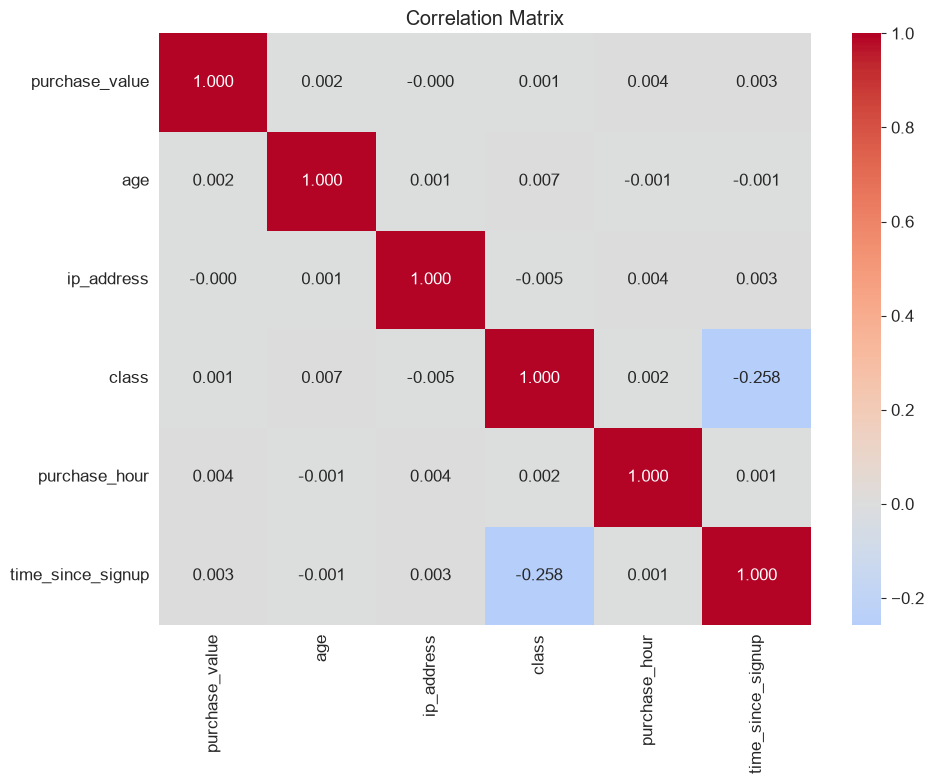

In [31]:
numeric_cols = ["purchase_value", "age", "ip_address" if "ip_address" in df.columns else "class",
                "class", "purchase_hour", "time_since_signup"]
numeric_cols = [c for c in numeric_cols if c in df.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".3f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Key Findings
- No missing values; minimal duplicates removed
- Highly imbalanced (~91% legitimate, ~9% fraud)
- Fraud rates vary by hour, browser, source, and purchase value range
- Fraudulent transactions often occur very quickly after signup